In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Import data
CSV_FILE = 'datasets/first_try.csv'
# CSV_FILE = 'datasets/add_lowpass_filter.csv'
df = pd.read_csv(CSV_FILE).drop('Unnamed: 0', axis=1)
df.head()

print(df.skill_type.unique())
mapping = {'clear': 0, 'drive': 1, 'drop': 2, 'lob': 3, 'smash': 4}
df['skill_type'] = df['skill_type'].map(mapping)
df.head()

['clear' 'drive' 'drop' 'lob' 'smash']


,skill_type,user,sample_number,time,X_Accelerometer,Y_Accelerometer,Z_Accelerometer,X_mean_Accelerometer,X_std_Accelerometer,Y_mean_Accelerometer,...,Z_std_Linear Accelerometer,X_Magnetometer,Y_Magnetometer,Z_Magnetometer,X_mean_Magnetometer,X_std_Magnetometer,Y_mean_Magnetometer,Y_std_Magnetometer,Z_mean_Magnetometer,Z_std_Magnetometer
0,0,alan,0.0,0.99,9.532627,-3.463498,-5.186564,8.884264,2.020677,-4.667240,...,2.052805,53.463146,10.586741,-3.011719,53.719987,0.480344,-7.500936,5.053261,2.766956,4.169675
1,0,alan,0.0,1.49,0.916843,11.289224,-4.045936,7.542038,2.854736,-0.826307,...,1.730399,25.985313,45.910320,-6.320366,47.038437,8.888797,12.751919,21.468403,-3.021415,4.578404
2,0,alan,0.0,1.99,25.937762,-32.929573,-22.564078,4.742197,7.173117,-0.920500,...,9.301322,17.093246,47.184288,-16.136497,20.987808,23.232288,37.203971,10.821606,5.803839,18.431575
3,0,alan,0.0,2.49,1.929188,-8.396489,-3.184328,6.102806,9.297669,-11.145731,...,11.571172,28.511925,-24.980471,-35.923805,14.495936,17.334938,16.134822,30.823548,-9.443157,31.364303
4,0,alan,0.0,2.99,4.673282,-6.567443,-1.064137,6.554884,6.092930,-12.992671,...,5.984026,40.401848,-15.435514,-29.398560,28.738258,3.908475,-14.923728,16.081408,-37.505341,4.380153


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.drop(columns="skill_type user sample_number time".split()).copy()
t = df['skill_type']
X.head()

X_train, X_test, y_train, y_test = train_test_split(X, t, test_size = 0.25, random_state = 32)

# rf = RandomForestClassifier(n_estimators = 100, random_state = 32)
#
# param_grid = {
#     'n_estimators': [200, 300, 500],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'max_depth' : [4,5,6,7,8],
#     'criterion' :['gini', 'entropy']
# }
#
# CV_rfc = GridSearchCV(estimator=rf, param_grid=param_grid, cv= 5)
# CV_rfc.fit(X_train, y_train)
# CV_rfc.best_params_

# rfc=RandomForestClassifier(random_state=32, max_features='sqrt',
#                            n_estimators= 500, max_depth=6, criterion='entropy')
# rfc.fit(X_train, y_train)
# y_pred=rfc.predict(X_test)
# confusion_hard = confusion_matrix(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)
# print(classification_report(y_test, y_pred))

rfc_base=RandomForestClassifier(random_state=42)
rfc_base.fit(X_train, y_train)

y_pred=rfc_base.predict(X_test)
print(classification_report(y_test, y_pred))

# y_train_pred = rfc_base.predict(X_train)
# print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.66      0.74      0.70        47
           1       0.64      0.81      0.72        36
           2       0.63      0.68      0.66        28
           3       0.92      0.86      0.89        28
           4       0.64      0.46      0.54        54

    accuracy                           0.68       193
   macro avg       0.70      0.71      0.70       193
weighted avg       0.69      0.68      0.68       193



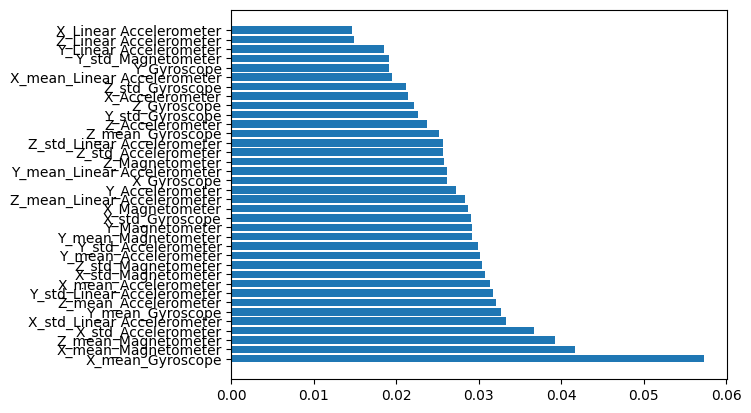

In [46]:
#Feature importance
feature_importance = pd.DataFrame(rfc_base.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance',ascending=False)

fig = plt.figure()
plt.barh(feature_importance.index, feature_importance.importance)
# If you want to define your own labels,
# change indices to a list of labels on the following line.
#plt.yticks(range(X.shape[1]), indices)
#plt.ylim([-1, X.shape[1]])
plt.show()